In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
df = pd.read_csv('single_genre_artists.csv')

In [3]:
df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [4]:
df.shape

(95837, 23)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  vale

In [6]:
df.isnull().sum()


id_songs              0
name_song             0
popularity_songs      0
duration_ms           0
explicit              0
id_artists            0
release_date          0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
followers             0
genres                0
name_artists          0
popularity_artists    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.nunique()

id_songs              95837
name_song             85427
popularity_songs         94
duration_ms           44685
explicit                  2
id_artists            18009
release_date          10436
danceability            996
energy                 1928
key                      12
loudness              19919
mode                      2
speechiness            1648
acousticness           3946
instrumentalness       5356
liveness               1713
valence                1595
tempo                 58312
time_signature            5
followers             11585
genres                 3153
name_artists          17662
popularity_artists       93
dtype: int64

In [9]:
df = df.drop(columns=['id_songs','name_song', 'name_artists', 'id_artists'])

In [10]:
df.shape

(95837, 19)

In [11]:
df.describe()


,popularity_songs,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,popularity_artists
count,95837.000000,9.583700e+04,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,9.583700e+04,95837.000000
mean,26.066394,2.087320e+05,0.029644,0.586853,0.541083,5.196782,-10.157862,0.648069,0.168832,0.458989,0.082145,0.224916,0.574281,117.539870,3.851362,1.979919e+05,42.819329
std,16.254133,1.177526e+05,0.169604,0.155422,0.236304,3.534923,4.748798,0.477575,0.275417,0.330416,0.232440,0.185829,0.248126,30.190399,0.544406,7.807520e+05,20.897833
min,0.000000,6.373000e+03,0.000000,0.000000,0.000020,0.000000,-50.174000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,13.000000,1.573330e+05,0.000000,0.488000,0.365000,2.000000,-12.723000,0.000000,0.034100,0.133000,0.000000,0.100000,0.378000,94.829000,4.000000,2.563000e+03,28.000000
50%,26.000000,2.040000e+05,0.000000,0.605000,0.542000,5.000000,-9.397000,1.000000,0.046200,0.453000,0.000004,0.149000,0.589000,116.595000,4.000000,1.595600e+04,40.000000
75%,37.000000,2.502670e+05,0.000000,0.700000,0.727000,8.000000,-6.692000,1.000000,0.103000,0.759000,0.001300,0.302000,0.780000,135.975000,4.000000,8.495100e+04,56.000000
max,98.000000,4.800118e+06,1.000000,0.991000,1.000000,11.000000,5.376000,1.000000,0.968000,0.996000,1.000000,0.997000,1.000000,239.906000,5.000000,2.802643e+07,95.000000


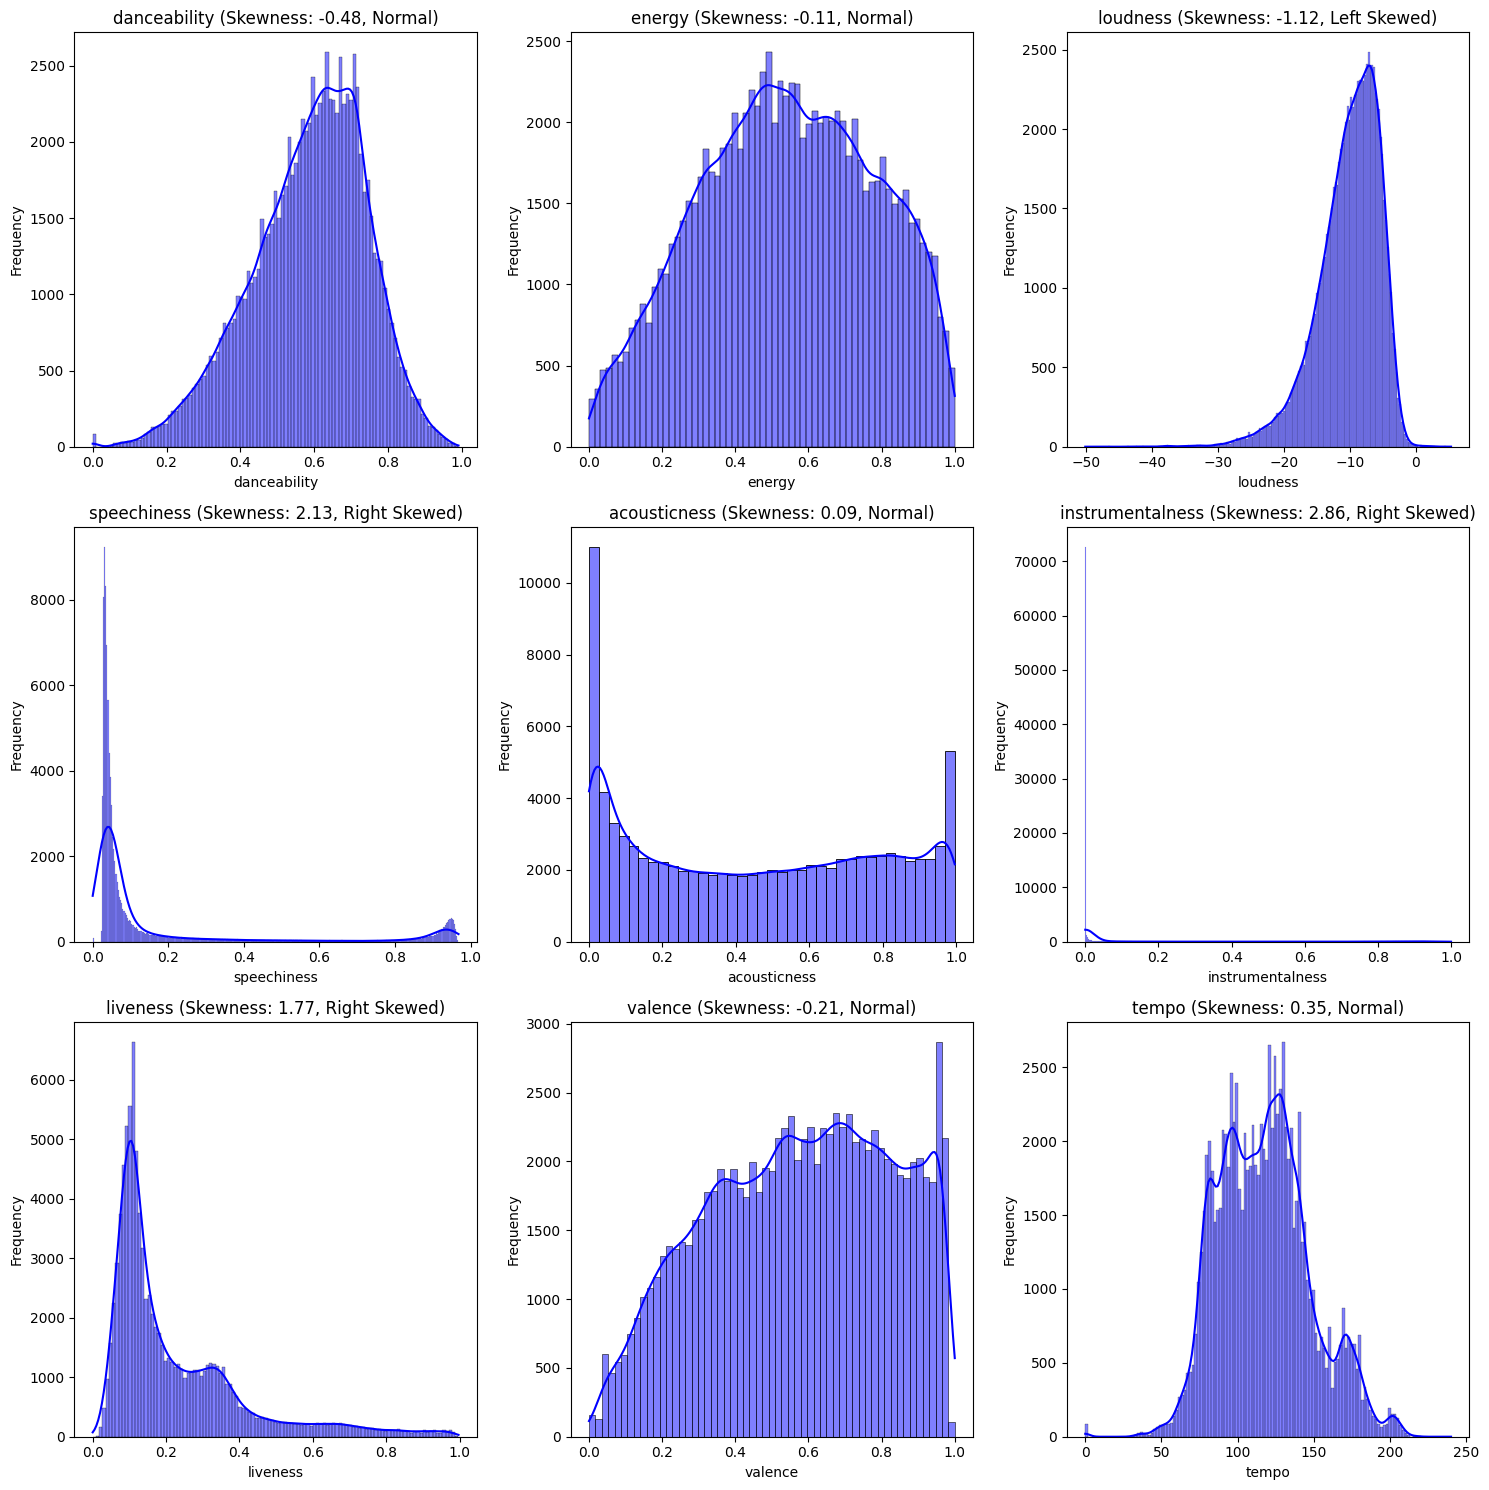

In [13]:
features = ['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness',
            'valence','tempo']
X = df[features].copy()

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    
    # Skewness
    skew_value = X[col].skew()
    
    if skew_value > 1:
        skew_type = "Right Skewed"
    elif skew_value < -1:
        skew_type = "Left Skewed"
    else:
        skew_type = "Normal"
    
    # Histogram
    sns.histplot(X[col], ax=axes[i], kde=True, color='blue')
    axes[i].set_title(f"{col} (Skewness: {skew_value:.2f}, {skew_type})")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [14]:
# Apply Log Transformation
X['speechiness'] = np.log1p(X['speechiness'])
X['liveness'] = np.log1p(X['liveness'])
X['instrumentalness'] = np.log1p(X['instrumentalness'])

In [15]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.clip(df[col], lower, upper)

for col in features:
    cap_outliers(X, col)

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=df.index)
print(X_scaled_df.head())


   danceability    energy  loudness  speechiness  acousticness  \
0     -0.157442 -1.511128 -0.826909    -0.437789      1.616187   
1     -1.039651 -1.528056 -1.189864    -0.195792      1.604081   
2     -0.494758 -1.418027 -1.221045    -0.314808      1.622240   
3      0.575570 -0.313510 -0.520933     1.229563      1.610134   
4      0.406912 -1.028695 -0.837901     0.849197      1.610134   

   instrumentalness  liveness   valence     tempo  
0         -0.603136  0.720059  0.321287  0.519910  
1         -0.614655 -0.541424 -0.577455 -1.304206  
2         -0.614655  1.251677 -0.375943 -1.571868  
3         -0.614655  0.066602  0.611464  0.409286  
4         -0.614655  0.998941  1.087031 -1.387984  


Best number of clusters (k): 3


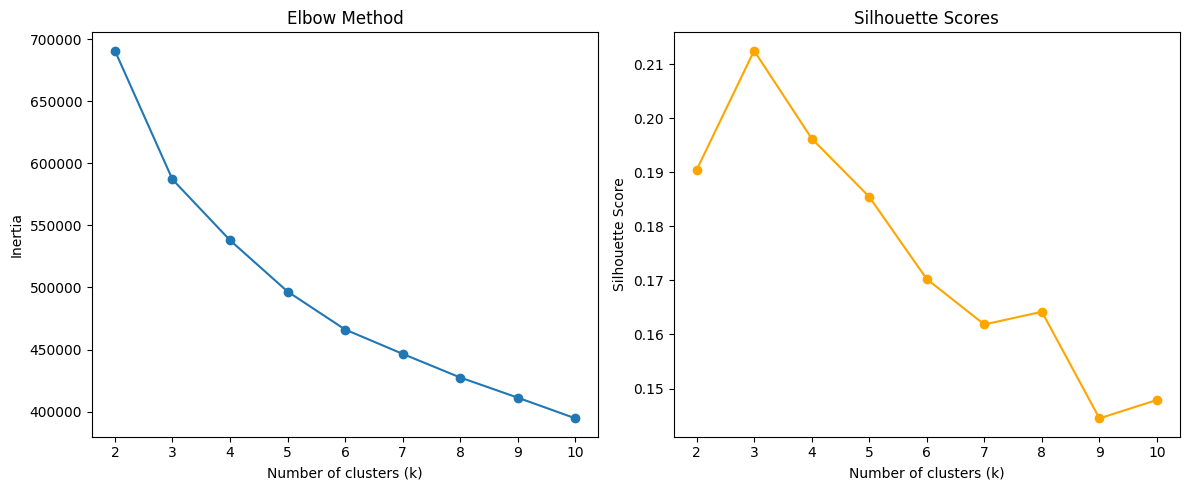

In [20]:
# ================================
# 9. ELBOW METHOD
# ================================

inertia = []
silhouette_scores = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled_df)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_df, labels))

best_k = K[np.argmax(silhouette_scores)]
print(f"Best number of clusters (k): {best_k}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Scores')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()


In [21]:
# ================================
# 11. FINAL K-MEANS MODEL
# ================================
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Kmean_Cluster']  = kmeans_final.fit_predict(X_scaled_df)
print(df['Kmean_Cluster'].value_counts())

Kmean_Cluster
1    48101
0    29658
2    18078
Name: count, dtype: int64


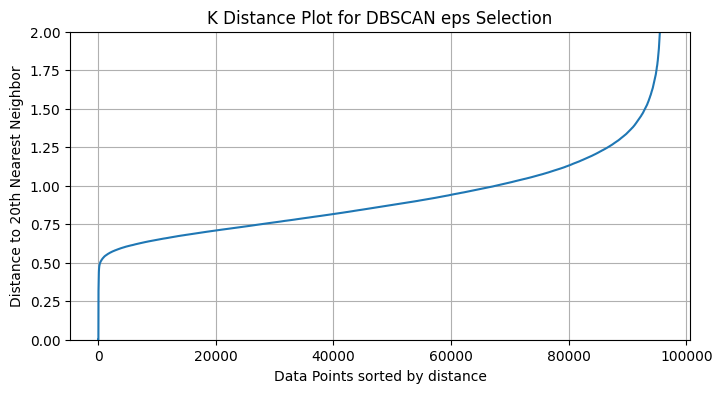

In [26]:
# DBSCAN (for discovering arbitrary-shaped clusters)

from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=20)
neighbors.fit(X_scaled_df)
distances, indices = neighbors.kneighbors(X_scaled_df)

#sort by distance
sorted_distances = np.sort(distances [:, 19])  # 19th index for 20th nearest neighbor

plt.figure(figsize=(8, 4))
plt.plot(sorted_distances)
plt.ylim(0, 2)  # Adjust y-axis limit for better visualization
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Distance to 20th Nearest Neighbor')
plt.title('K Distance Plot for DBSCAN eps Selection')
plt.grid()
plt.show()

In [27]:
# Apply DBSCAN

eps_values = [0.6, 0.8, 1.0, 1.1, 1.2, 1.3]

results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=15)
    labels = dbscan.fit_predict(X_scaled_df)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = np.sum(labels == -1)

    results.append((eps, n_clusters, noise))

    print(f"eps={eps}, clusters={n_clusters}, noise={noise}")


eps=0.6, clusters=55, noise=74614
eps=0.8, clusters=16, noise=30016
eps=1.0, clusters=5, noise=8821
eps=1.1, clusters=3, noise=4592
eps=1.2, clusters=2, noise=2505
eps=1.3, clusters=1, noise=1382


In [28]:
eps = 1.1
min_samples = 15

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled_df)

df['DBSCAN_Cluster'] = labels
print(df['DBSCAN_Cluster'].value_counts())
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = np.sum(labels == -1)

print("Clusters:", n_clusters)
print("Noise points:", noise)

DBSCAN_Cluster
 0    91209
-1     4592
 2       26
 1       10
Name: count, dtype: int64
Clusters: 3
Noise points: 4592


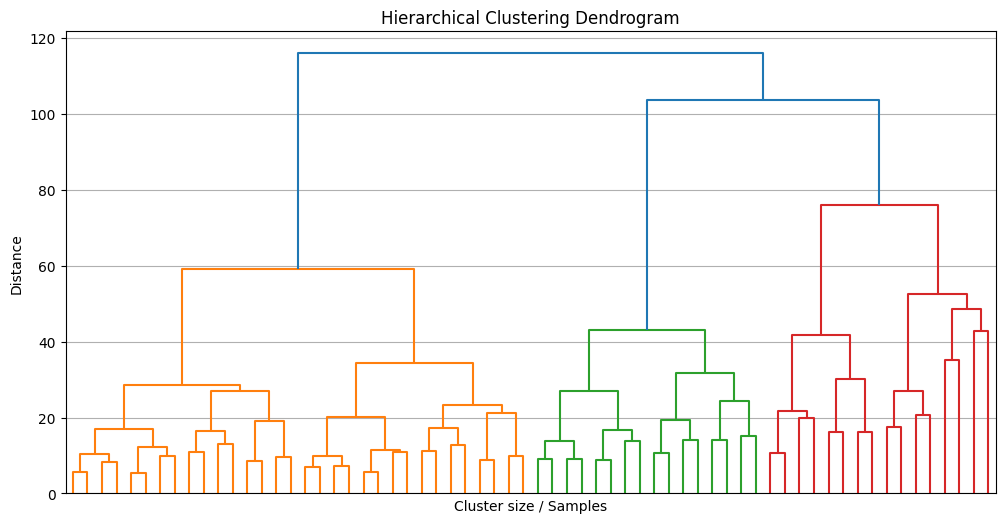

In [29]:
# Create Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

# Use sample for performance
sample_df = X_scaled_df.sample(n=5000, random_state= 42).values
linked = linkage(sample_df, method='ward')

# Plot dendrogram (optimized)
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='level', p =5, no_labels=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster size / Samples')
plt.ylabel('Distance')
plt.grid()
plt.show()

In [34]:
# Apply Agglomerative Clustering

df_sample = X_scaled_df.sample(n=5000, random_state=42)

agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = agglo.fit_predict(df_sample)

sample_labels = pd.Series(labels, index=df_sample.index)
df['Agglo_Cluster'] = -1  # Initialize with -1 for all
df.loc[sample_labels.index, 'Agglo_Cluster'] = sample_labels.values

print(sample_labels.value_counts())

0    2939
1    1192
2     869
Name: count, dtype: int64


In [37]:
def evaluate(name, X, labels):
    print(f"\n{name}")
    print("Silhouette Score:", silhouette_score(X, labels))
    print("Davies-Bouldin Score:", davies_bouldin_score(X, labels))


# KMeans (full data)
evaluate("KMeans", X_scaled_df, df['Kmean_Cluster'])


# Agglomerative (only sampled points)
mask_agg = df['Agglo_Cluster'] != -1
evaluate("Agglomerative", X_scaled_df[mask_agg], df.loc[mask_agg, 'Agglo_Cluster'])


# DBSCAN (exclude noise)
mask_db = df['DBSCAN_Cluster'] != -1
evaluate("DBSCAN", X_scaled_df[mask_db], df.loc[mask_db, 'DBSCAN_Cluster'])


KMeans
Silhouette Score: 0.21246569204635332
Davies-Bouldin Score: 1.590172725262249

Agglomerative
Silhouette Score: 0.17512745137817698
Davies-Bouldin Score: 1.7372076290982115

DBSCAN
Silhouette Score: 0.03616437223309901
Davies-Bouldin Score: 1.0183571879060613


# DBSCAN did not perform well due to continuous feature distribution
# and lack of clear density separation in the dataset

In [83]:
print("\nBest Model: KMeans")
print("Reason: Highest Silhouette Score and better cluster separation")


Best Model: KMeans
Reason: Highest Silhouette Score and better cluster separation


In [39]:
# 1. Cluster Summary (Mean values)
cluster_summary = df.groupby('Kmean_Cluster')[features].mean()

print("\n📊 Cluster Summary (Feature Means):\n")
print(cluster_summary)


📊 Cluster Summary (Feature Means):

               danceability    energy   loudness  speechiness  acousticness  \
Kmean_Cluster                                                                 
0                  0.478774  0.314443 -13.085535     0.046104      0.737700   
1                  0.623831  0.703118  -7.460877     0.062274      0.246684   
2                  0.665778  0.481765 -12.530843     0.653700      0.566635   

               instrumentalness  liveness   valence       tempo  
Kmean_Cluster                                                    
0                      0.164931  0.176670  0.403726  112.247171  
1                      0.058215  0.192426  0.670078  126.104661  
2                      0.010001  0.390515  0.599193  103.434095  


🟢 Cluster 0 → “Chill Acoustic / Soft Music”
🔍 Key characteristics:
Low energy (0.31) → calm, relaxed
Very high acousticness (0.73) → acoustic instruments
Low loudness (-13 dB) → soft sound
Low valence (0.40) → slightly sad / mellow
Moderate instrumentalness (0.16)
🎵 Interpretation:

Soft, calm, acoustic songs — often emotional or relaxing

🏷️ Label:

✅ “Chill Acoustic” or “Soft / Relaxing Tracks”

🔴 Cluster 1 → “Party / Energetic Pop”
🔍 Key characteristics:
High energy (0.70) → very energetic
High danceability (0.62) → dance-friendly
High loudness (-7.46) → loud / club music
High valence (0.67) → happy, positive
Low acousticness (0.24) → electronic / produced
🎵 Interpretation:

Upbeat, energetic, danceable songs

🏷️ Label:

✅ “Party Tracks” or “Energetic Pop”

🟡 Cluster 2 → “Rap / Spoken / Live”
🔍 Key characteristics:
Very high speechiness (0.65) 🔥 → strong spoken/rap content
High liveness (0.39) → live feel / audience presence
Moderate acousticness (0.56)
Medium energy (0.48)
Good danceability (0.66)

In [40]:
cluster_names = {
    0: "Chill Acoustic",
    1: "Party Tracks",
    2: "Rap / Spoken"
}

df['Cluster_Name'] = df['Kmean_Cluster'].map(cluster_names)

In [82]:
print("\n🎵 Cluster Name Distribution:\n")
print(df['Cluster_Name'].value_counts(normalize=True))



🎵 Cluster Name Distribution:

Cluster_Name
Party Tracks      0.501904
Chill Acoustic    0.309463
Rap / Spoken      0.188633
Name: proportion, dtype: float64


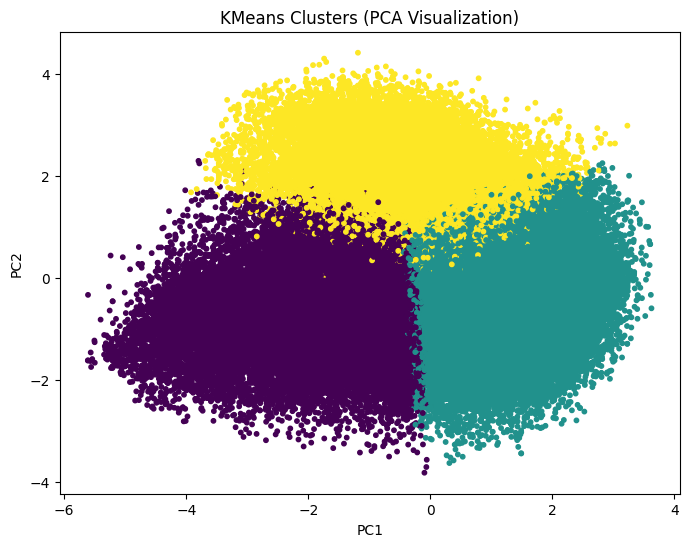

In [42]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Kmean_Cluster'], cmap='viridis', s=10)
plt.title("KMeans Clusters (PCA Visualization)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

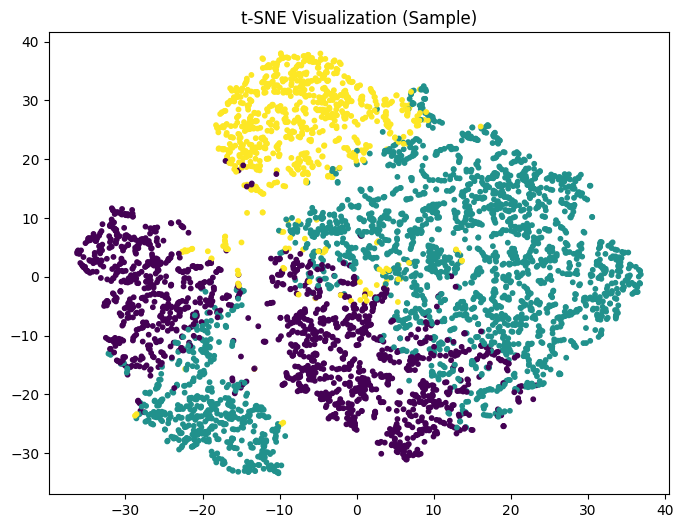

In [86]:
from sklearn.manifold import TSNE

sample = X_scaled_df.sample(5000, random_state=42)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=500)
X_tsne = tsne.fit_transform(sample)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1],
            c=df.loc[sample.index, 'Kmean_Cluster'],
            cmap='viridis', s=10)
plt.title("t-SNE Visualization (Sample)")
plt.show()

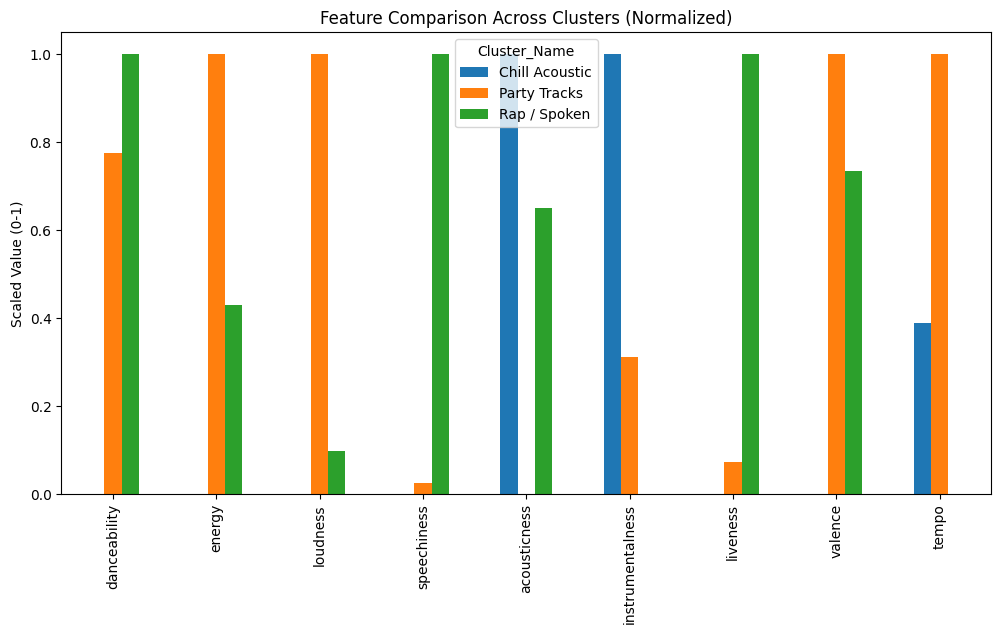

In [66]:
from sklearn.preprocessing import MinMaxScaler

cluster_summary = df.groupby('Cluster_Name')[features].mean()

scaler = MinMaxScaler()

cluster_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_summary),
    columns=cluster_summary.columns,
    index=cluster_summary.index
)

cluster_scaled.T.plot(kind='bar', figsize=(12,6))
plt.title("Feature Comparison Across Clusters (Normalized)")
plt.ylabel("Scaled Value (0-1)")
plt.show()

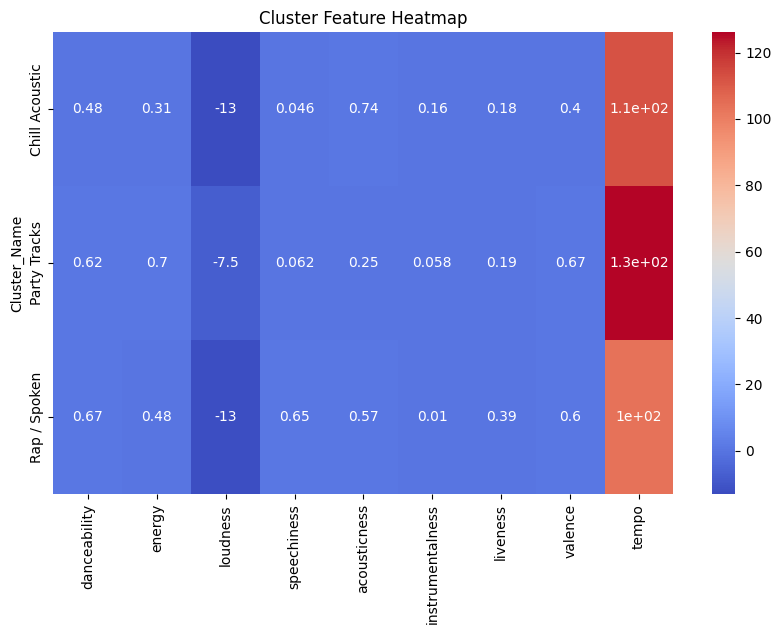

In [67]:
plt.figure(figsize=(10,6))
sns.heatmap(cluster_summary, annot=True, cmap='coolwarm')
plt.title("Cluster Feature Heatmap")
plt.show()

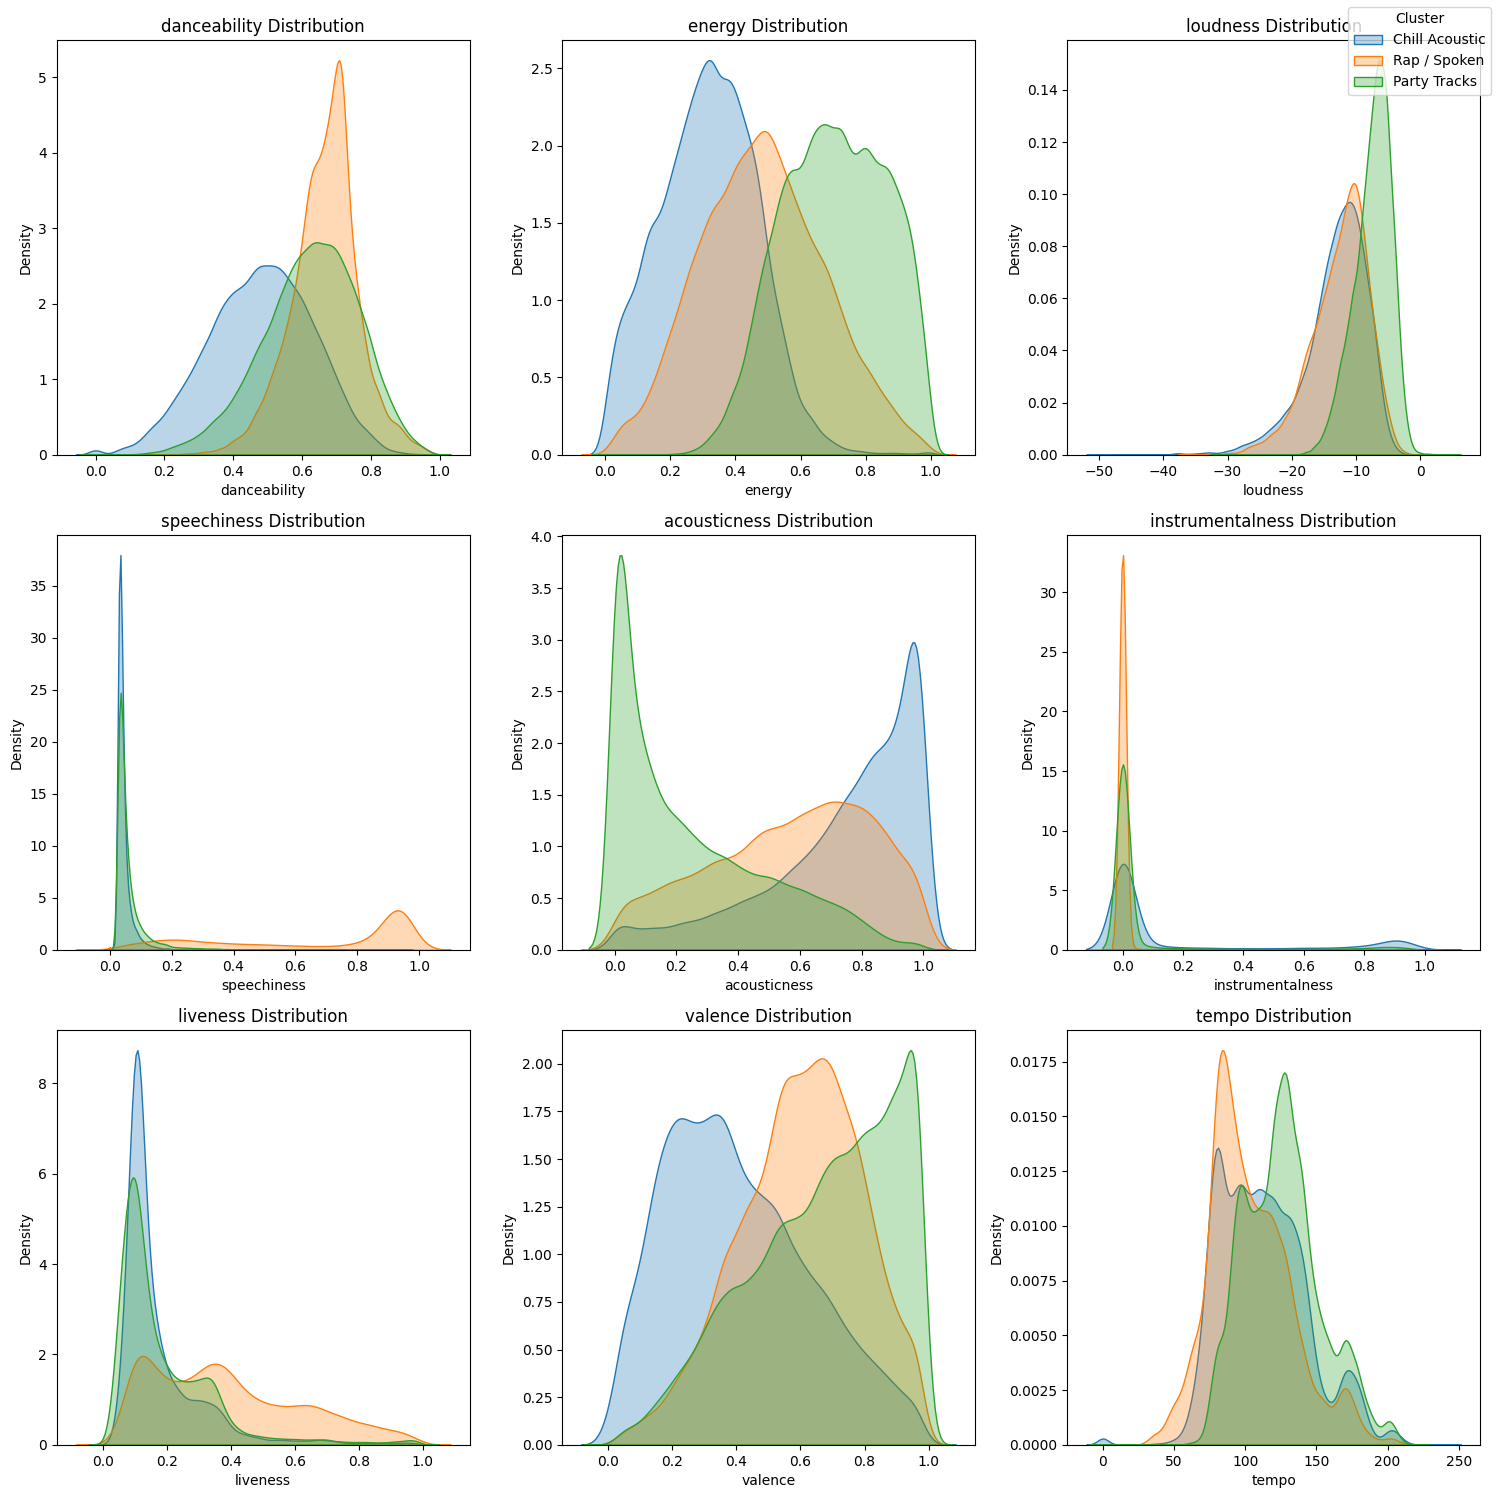

In [80]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))
axes = axes.flatten()

for idx, col in enumerate(X.columns):
    
    ax = axes[idx]
    
    for cluster in df['Cluster_Name'].unique():
        sns.kdeplot(
            df[df['Cluster_Name'] == cluster][col],
            label=cluster,
            fill=True,
            alpha=0.3,
            ax=ax
        )
    
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

# Add legend once (outside loop)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Cluster", loc='upper right')

plt.tight_layout()
plt.show()

In [69]:
for cluster in df['Cluster_Name'].unique():
    print(f"\n🎵 Cluster {cluster} Top Samples:")
    print(df[df['Cluster_Name'] == cluster][
        ['genres', 'popularity_songs', 'danceability', 'energy']
    ].head(5))


🎵 Cluster Chill Acoustic Top Samples:
                genres  popularity_songs  danceability  energy
0  ['vintage chanson']                 0         0.563   0.184
1  ['vintage chanson']                 0         0.427   0.180
2  ['vintage chanson']                 0         0.511   0.206
6  ['vintage chanson']                 0         0.515   0.249
8  ['vintage chanson']                 0         0.582   0.371

🎵 Cluster Rap / Spoken Top Samples:
                 genres  popularity_songs  danceability  energy
3   ['vintage chanson']                 0         0.676   0.467
4   ['vintage chanson']                 0         0.650   0.298
5   ['vintage chanson']                 0         0.671   0.454
7   ['vintage chanson']                 0         0.415   0.330
15  ['vintage chanson']                 0         0.760   0.366

🎵 Cluster Party Tracks Top Samples:
                   genres  popularity_songs  danceability  energy
34    ['vintage chanson']                 0         0.650  

In [73]:
for cluster in df['Cluster_Name'].unique():
    print(f"\n================ Cluster {cluster} ================")
    
    # Summary stats
    print("\nFeature Summary:")
    print(df[df['Cluster_Name'] == cluster][features].mean().round(2).sort_values())


================ Cluster Chill Acoustic ================

Feature Summary:
loudness            -13.09
speechiness           0.05
instrumentalness      0.16
liveness              0.18
energy                0.31
valence               0.40
danceability          0.48
acousticness          0.74
tempo               112.25
dtype: float64

================ Cluster Rap / Spoken ================

Feature Summary:
loudness            -12.53
instrumentalness      0.01
liveness              0.39
energy                0.48
acousticness          0.57
valence               0.60
speechiness           0.65
danceability          0.67
tempo               103.43
dtype: float64

================ Cluster Party Tracks ================

Feature Summary:
loudness             -7.46
speechiness           0.06
instrumentalness      0.06
liveness              0.19
acousticness          0.25
danceability          0.62
valence               0.67
energy                0.70
tempo               126.10
dtype: float64


In [74]:
for cluster in df['Cluster_Name'].unique():
    print(f"\n🎵 Cluster {cluster} Top Popular Songs:")
    
    print(
        df[df['Cluster_Name'] == cluster]
        .sort_values(by='popularity_songs', ascending=False)
        [['genres', 'popularity_songs', 'danceability', 'energy']]
        .head(5)
    )


🎵 Cluster Chill Acoustic Top Popular Songs:
                         genres  popularity_songs  danceability  energy
35233             ['dutch pop']                89         0.450   0.329
35436           ['bedroom pop']                87         0.399   0.491
35234             ['dutch pop']                83         0.453   0.350
34858          ['acoustic pop']                83         0.618   0.443
34884  ['contemporary country']                80         0.551   0.402

🎵 Cluster Rap / Spoken Top Popular Songs:
                   genres  popularity_songs  danceability  energy
35241  ['brooklyn drill']                91         0.709   0.548
35287     ['chicago rap']                89         0.789   0.536
35284     ['chicago rap']                88         0.832   0.534
35239  ['brooklyn drill']                86         0.548   0.805
35462         ['sad rap']                85         0.980   0.413

🎵 Cluster Party Tracks Top Popular Songs:
                                         

In [75]:
for cluster in df['Cluster_Name'].unique():
    print(f"\n🎧 Cluster {cluster} Top Genres:")
    print(df[df['Cluster_Name'] == cluster]['genres'].value_counts().head(5))


🎧 Cluster Chill Acoustic Top Genres:
genres
['vintage taiwan pop']     1023
['classic israeli pop']     525
['chanson']                 493
['classic soundtrack']      436
['opm']                     402
Name: count, dtype: int64

🎧 Cluster Rap / Spoken Top Genres:
genres
['hoerspiel']           7877
['kleine hoerspiel']    2046
[]                       771
['psychedelic rock']     221
['barnmusik']            208
Name: count, dtype: int64

🎧 Cluster Party Tracks Top Genres:
genres
['j-pop']               806
[]                      769
['turkish pop']         606
['classic thai pop']    536
['rock uruguayo']       505
Name: count, dtype: int64


In [76]:
df.groupby('Cluster_Name')['popularity_songs'].mean()

Cluster_Name
Chill Acoustic    21.086587
Party Tracks      28.590383
Rap / Spoken      27.520356
Name: popularity_songs, dtype: float64

In [85]:
def recommend_songs(song_index, df, n=5):
    cluster = df.loc[song_index, 'Cluster_Name']
    return df[df['Cluster_Name'] == cluster].sample(n)

print(recommend_songs(0, df))

       popularity_songs  duration_ms  explicit release_date  danceability  \
43456                23       123973         0   1968-01-30         0.391   
2128                  6       182587         0         1956         0.261   
80005                12       307563         0         1965         0.288   
512                   0       192053         0         1927         0.340   
6305                 17       271533         0         1964         0.510   

       energy  key  loudness  mode  speechiness  ...  valence    tempo  \
43456   0.217    2   -18.972     1       0.1090  ...    0.618   84.028   
2128    0.233    8   -15.209     0       0.0415  ...    0.472   59.333   
80005   0.703    1    -5.951     1       0.0450  ...    0.500   81.325   
512     0.213    5   -12.556     0       0.0407  ...    0.241   90.351   
6305    0.263    4   -18.543     0       0.0380  ...    0.501  106.253   

       time_signature  followers  \
43456               4        4.0   
2128                

In [58]:
df.to_csv("clustered_songs.csv", index=False)